(a) Normalized 5×5 Gaussian Kernel (sigma = 2)

In [3]:
import numpy as np

def gaussian_kernel(size=5, sigma=2):
    """Compute a normalized 2D Gaussian kernel."""
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

kernel_5x5 = gaussian_kernel(5, 2)
print("5x5 Gaussian Kernel (σ=2):\n", kernel_5x5)


5x5 Gaussian Kernel (σ=2):
 [[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


(b) Visualize 51×51 Kernel as 3D Surface

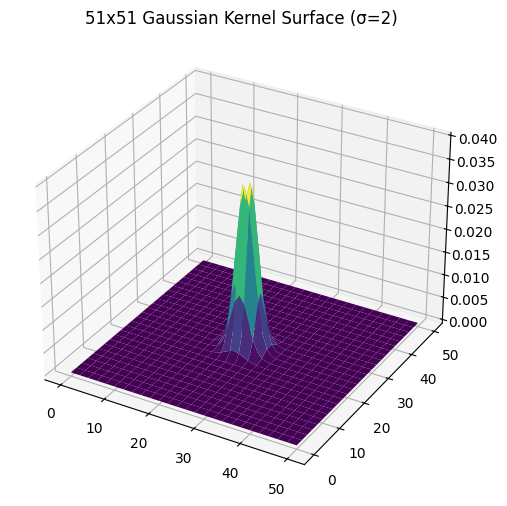

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

kernel_51x51 = gaussian_kernel(51, 2)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(np.arange(51), np.arange(51))
ax.plot_surface(X, Y, kernel_51x51, cmap='viridis')
ax.set_title("51x51 Gaussian Kernel Surface (σ=2)")
plt.show()


(c) Apply Gaussian Smoothing with Manual Kernel

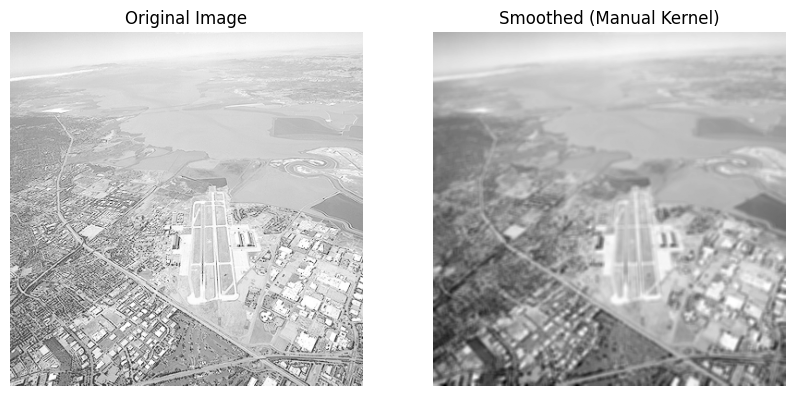

In [9]:
import cv2 as cv

#load the image in grayscale mode
f = cv.imread('/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 01/runway.png', cv.IMREAD_REDUCED_GRAYSCALE_2)
assert f is not None

# Apply convolution with custom kernel
smoothed_manual = cv.filter2D(f, -1, kernel_5x5)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(f, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Smoothed (Manual Kernel)")
plt.imshow(smoothed_manual, cmap='gray')
plt.axis("off")
plt.show()


(d) Apply Gaussian Smoothing with OpenCV

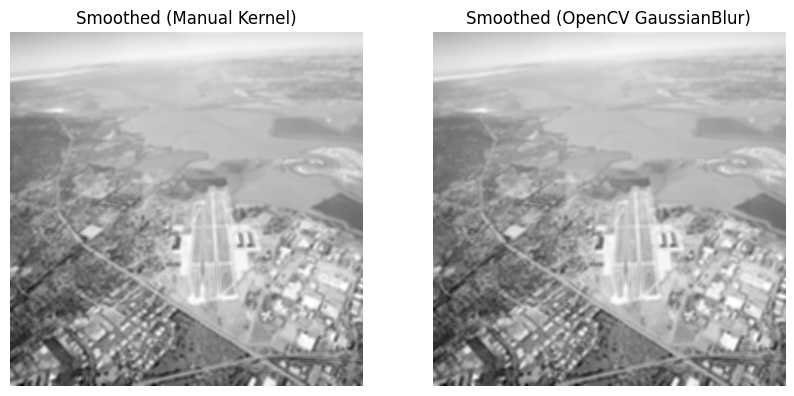

In [10]:
# Using OpenCV's built-in GaussianBlur
smoothed_cv = cv.GaussianBlur(f, (5,5), 2)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Smoothed (Manual Kernel)")
plt.imshow(smoothed_manual, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Smoothed (OpenCV GaussianBlur)")
plt.imshow(smoothed_cv, cmap='gray')
plt.axis("off")
plt.show()
